In [72]:
# Стандартные библиотеки для воспроизводимости и работы с массивами
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge

# PyTorch: нейросетевые блоки и работа с данными
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# scikit-learn: разбиение данных, baseline-модель, метрики
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

print('pd:', pd.__version__)
print('np:', np.__version__)
print('sklearn:', sklearn.__version__)


pd: 2.3.3
np: 2.3.5
sklearn: 1.7.2


In [73]:
def set_seed(seed: int = 42):
    """Фиксирует все источники случайности для воспроизводимости результатов."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Используем GPU, если доступен, иначе – CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

device = cpu


In [74]:
df = pd.read_csv('data/S12-hw-dataset.csv')

df['date'] = pd.to_datetime(df['date'])

df = df.reset_index(drop=True)

In [75]:
display(df.head())

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [76]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4320 non-null   datetime64[ns]
 1   target  4320 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 67.6 KB


None

In [77]:
display(df.describe())

,date,target
count,4320,4320.000000
mean,2025-03-31 23:29:59.999999744,135.605840
min,2025-01-01 00:00:00,69.100000
25%,2025-02-14 23:45:00,120.537500
50%,2025-03-31 23:30:00,135.835000
75%,2025-05-15 23:15:00,150.625000
max,2025-06-29 23:00:00,210.100000
std,NaN,21.384633


In [78]:
print('число наблюдений:', df.shape[0])

print('диапазон дат:', min(df['date']), "-", max(df['date']))

число наблюдений: 4320
диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00


In [79]:
print(df.columns)
print(df['date'].isna().mean())
print(df['target'].isna().mean())

df = df.dropna()

print("\nПосле удаления пропусков:")
print(f"Пропуски в 'date': {df['date'].isna().mean()}")
print(f"Пропуски в 'target': {df['target'].isna().mean()}")
print(f"Размер данных после очистки: {df.shape}")

Index(['date', 'target'], dtype='object')
0.0
0.0

После удаления пропусков:
Пропуски в 'date': 0.0
Пропуски в 'target': 0.0
Размер данных после очистки: (4320, 2)


In [80]:
df = df.sort_values('date')

,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:29:59.999999744,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


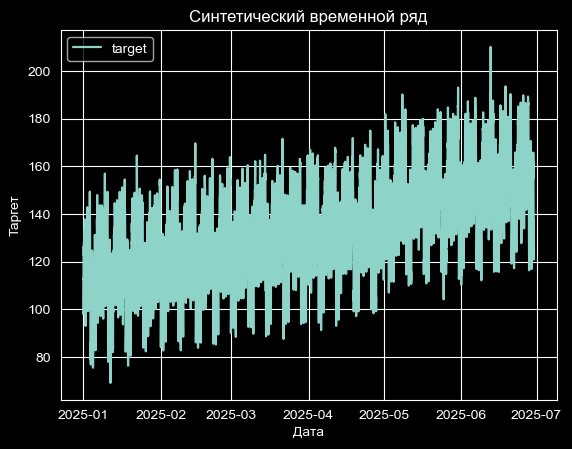

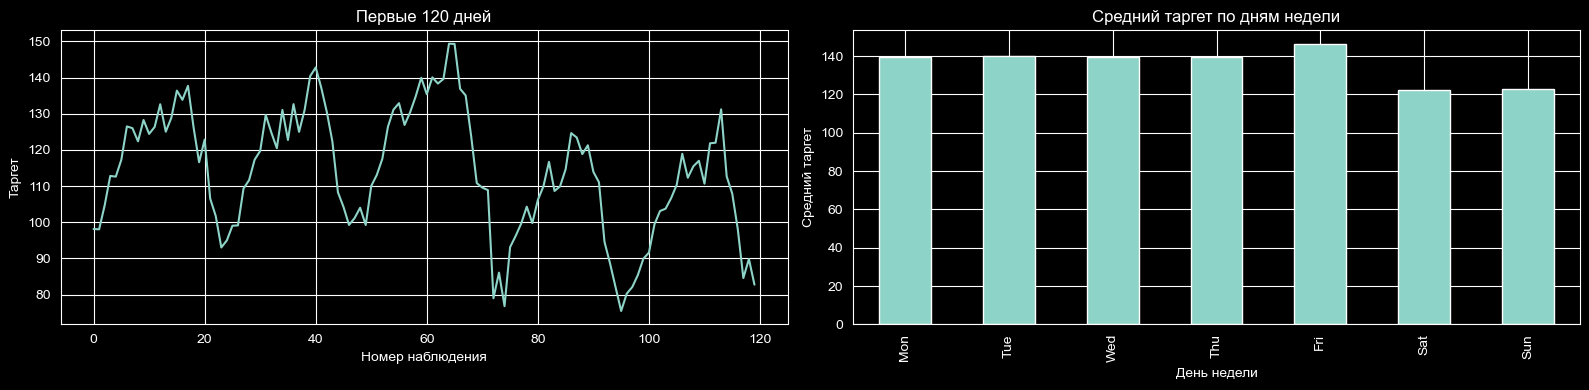

In [81]:
# Сначала смотрим сводную статистику, затем визуально проверяем форму ряда и сезонность.
display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.6, label="target")
ax.set_title("Синтетический временной ряд")
ax.set_xlabel("Дата")
ax.set_ylabel("Таргет")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Крупным планом видно локальную динамику и уровень шума в начале ряда.
df["target"].iloc[:120].plot(ax=axes[0], title="Первые 120 дней")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("Таргет")

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["target"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средний таргет по дням недели")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средний таргет")

plt.tight_layout()
plt.show()

Временной ряд демонстрирует очевидно восходящий тренд, со временем значения показателя target увеличиваются. Можно заметить регулярные колебания, которые свидетельствуют о наличии сезонности в данных (особенно выражены регулярные изменения значений по дням недели на гистограмме в правом нижнем углу). На графике видны значительные выбросы, которые выходят за пределы общего диапазона колебаний ряда. Ряд является нестационарным из-за наличия тренда.

In [82]:
# Конфигурация разбиения временного ряда
@dataclass
class SplitConfig:
    train_frac: float = 0.70  # 70% для обучения
    val_frac: float = 0.15    # 15% для валидации, остальное для теста

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    """
    Разбивает временной ряд на train/val/test по хронологии.
    ВАЖНО: не случайное разбиение, а последовательное по времени!
    Модель учится на прошлом и тестируется на будущем.
    """
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()          # Ранний период
    val_df = df.iloc[train_end:val_end].copy()     # Средний период
    test_df = df.iloc[val_end:].copy()             # Поздний период
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (3024, 2), 2025-01-01 -> 2025-05-06
val  : (648, 2), 2025-05-07 -> 2025-06-02
test : (648, 2), 2025-06-03 -> 2025-06-29


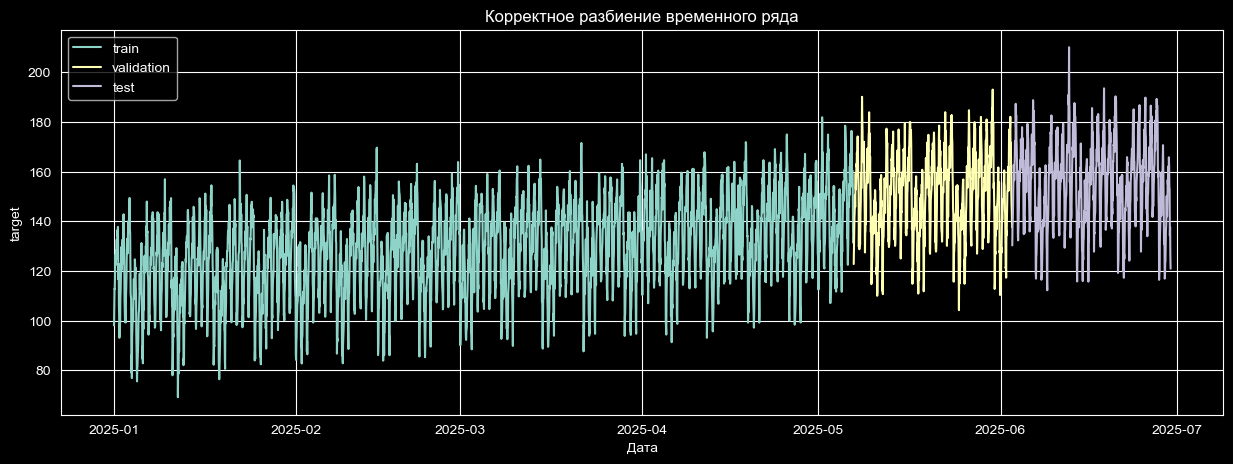

In [83]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректное разбиение временного ряда")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.savefig('artifacts/figures/series_split.png')
plt.show()

Для временного ряда надо используя прошлое, предсказать будущее, но если мы перемешаем наблюдения случайно с помощью random split, модель будет учиться на поздних датах и тестироваться на ранних. Для прогноза это нереалистично.

In [84]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek

    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()


    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,target,dayofweek,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 14:00:00,128.87,2,125.04,126.01,98.14,126.445714,3.275621
1,2025-01-01 15:00:00,136.40,2,128.87,122.38,98.07,126.854286,3.388632
2,2025-01-01 16:00:00,133.85,2,136.40,128.28,104.70,128.857143,4.318919
3,2025-01-01 17:00:00,137.71,2,133.85,124.43,112.81,129.652857,4.691868
4,2025-01-01 18:00:00,126.32,2,137.71,126.35,112.62,131.550000,4.907936


In [85]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "dayofweek", "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7"
]

target_col = "target"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (3014, 6) | y_train: (3014,)
X_val:   (646, 6) | y_val:   (646,)
X_test:  (646, 6) | y_test:  (646,)


In [86]:
# Небольшие вспомогательные функции для единообразной оценки всех моделей.
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])

# Naive baseline: завтрашнее значение равно последнему наблюдённому.
val_pred_naive = val_feat["lag_1"].to_numpy()


# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()


baseline_results_val = pd.concat([
    evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)

print("Validation:")
display(baseline_results_val)

Validation:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.443406,8.203532,4.394594
1,MovingAverage(7),12.723717,15.236326,8.828779


In [87]:
# Ridge чувствителен к масштабу признаков, поэтому его обучаем на стандартизованных данных.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)

val_results = pd.concat([
    baseline_results_val,
    evaluate_regression(y_val, val_pred_ridge, "Ridge"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("Validation:")
display(val_results)

Validation:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.443406,8.203532,4.394594
1,Ridge,7.171741,8.723752,4.782421
2,MovingAverage(7),12.723717,15.236326,8.828779


In [88]:
# 1. Нормализация данных ТОЛЬКО по train набору (чтобы не было утечки информации)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

window_size = 28  # Глубина контекста: модель смотрит на 28 дней в прошлое

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (2996, 28, 1) y_train: (2996,)
X_val  : (620, 28, 1) y_val  : (620,)
X_test : (620, 28, 1) y_test : (620,)


In [89]:
# Определяем PyTorch Dataset для обработки последовательностей
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверяем форму батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


In [90]:
class GRUForecaster(nn.Module):
    """
    GRU-модель для временных рядов.
    GRU проще, чем LSTM: имеет 2 вентиля (reset и update) вместо 3, нет cell state.
    Часто работает лучше на малых датасетах благодаря меньшей сложности оптимизации.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [91]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [92]:
# Обучаем GRU с такими же параметрами как LSTM
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
print(gru_model)

GRU  params: 37889
GRUForecaster(
  (rnn): GRU(1, 64, num_layers=2, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)


In [93]:
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

Epoch 01 | train_loss=0.6994 | val_loss=0.6024
Epoch 02 | train_loss=0.2726 | val_loss=0.3549
Epoch 03 | train_loss=0.1632 | val_loss=0.2236
Epoch 04 | train_loss=0.1544 | val_loss=0.1980
Epoch 05 | train_loss=0.1512 | val_loss=0.1802
Epoch 06 | train_loss=0.1503 | val_loss=0.2615
Epoch 07 | train_loss=0.1463 | val_loss=0.2079
Epoch 08 | train_loss=0.1483 | val_loss=0.1745
Epoch 09 | train_loss=0.1463 | val_loss=0.3428
Epoch 10 | train_loss=0.1450 | val_loss=0.1793
Epoch 11 | train_loss=0.1419 | val_loss=0.2051
Epoch 12 | train_loss=0.1410 | val_loss=0.2272
Epoch 13 | train_loss=0.1373 | val_loss=0.2138
Epoch 14 | train_loss=0.1347 | val_loss=0.2043
Epoch 15 | train_loss=0.1305 | val_loss=0.2379
Epoch 16 | train_loss=0.1248 | val_loss=0.2244
Epoch 17 | train_loss=0.1172 | val_loss=0.1987
Epoch 18 | train_loss=0.1112 | val_loss=0.2192
Epoch 19 | train_loss=0.1129 | val_loss=0.1705
Epoch 20 | train_loss=0.1042 | val_loss=0.1719
Epoch 21 | train_loss=0.1053 | val_loss=0.1857
Epoch 22 | tr

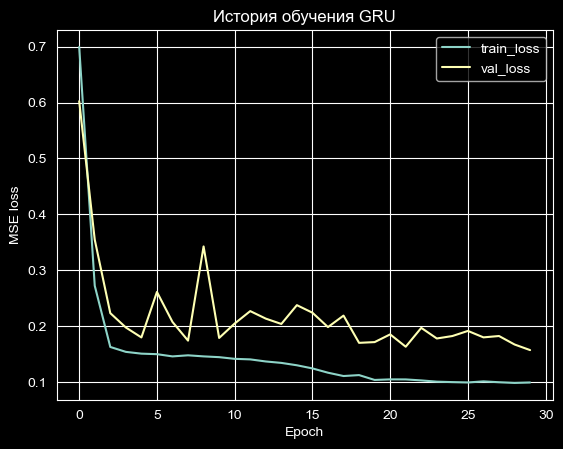

In [94]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig('artifacts/figures/gru_learning_curves.png')
plt.show()

In [95]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets

def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE_%": mape}

In [96]:

gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)


# Восстанавливаем исходный масштаб
val_true = inverse_scale(gru_val_true_scaled, scaler)

gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)


# Вычисляем метрики для каждой модели и сортируем по RMSE
val_results = pd.concat([
    val_results,
    evaluate_regression(val_true, gru_val_pred, "GRU"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

val_results

,model,MAE,RMSE,MAPE_%
0,GRU,5.720355,7.372209,3.862717
1,Naive (lag_1),6.443406,8.203532,4.394594
2,Ridge,7.171741,8.723752,4.782421
3,MovingAverage(7),12.723717,15.236326,8.828779


In [97]:
# Берём победителя по MAE на test и визуально проверяем, где именно он ошибается.
best_model_name = val_results.iloc[0]["model"]
print(f"Лучшая модель на val по MAE: {best_model_name}")

Лучшая модель на val по MAE: GRU


In [98]:
best_model = gru_model

# Оценка моделей на TEST (финальная проверка, на которую модель не смотрела во время обучения)

gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)


# Восстанавливаем исходный масштаб
test_true = inverse_scale(gru_test_true_scaled, scaler)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)


# Вычисляем финальные метрики
test_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(test_true, gru_test_pred)},
    ]
)

test_metrics

,model,MAE,RMSE,MAPE_%
0,GRU,6.944059,8.805502,4.462556


In [99]:
def get_metrics(df, model_name):
    row = df[df["model"] == model_name].iloc[0]
    return row["MAE"], row["RMSE"], row["MAPE_%"]

b1_val_mae, b1_val_rmse, b1_val_mape = get_metrics(val_results, "Naive (lag_1)")
b2_val_mae, b2_val_rmse, b2_val_mape = get_metrics(val_results, "MovingAverage(7)")
b3_val_mae, b3_val_rmse, b3_val_mape = get_metrics(val_results, "Ridge")
r1_val_mae, r1_val_rmse, r1_val_mape = get_metrics(val_results, "GRU")

In [100]:
runs = pd.DataFrame({
    "experiment_id": ["B1", "B2", "B3", "R1"],
    "task": ["forecasting"] * 4,
    "dataset": ["S12-hw-dataset.csv"] * 4,
    "seed": [42] * 4,
    "split_summary": [{"train": 0.7, "val": 0.15, "test": 0.15}] * 4,
    "window_size": [1, 7, None, window_size],
    "horizon": [1, 1, 1, 1],
    'model_summary': ['Naive (lag_1)', 'MovingAverage(7)', 'Ridge(alpha=1.0)', '''GRUForecaster(
        (rnn): GRU(1, 64, num_layers=2, batch_first=True)
        (head): Linear(in_features=64, out_features=1, bias=True)
        )'''
    ],
    'features_summary': ['lag_1', 'rolling_mean_7', ("dayofweek", "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7"), 'window=28'],
    'scaler': ['', '', 'StandardScaler', 'StandardScaler'],
    'optimizer': ['', '', '', 'Adam'],
    'lr': ['','','',5e-4],
    "epochs_trained": ['','','',len(gru_history['train_loss'])],
    "best_val_mae": [
        b1_val_mae,
        b2_val_mae,
        b3_val_mae,
        r1_val_mae
    ],
    "best_val_rmse": [
        b1_val_rmse,
        b2_val_rmse,
        b3_val_rmse,
        r1_val_rmse
    ],
    "best_val_mape": [
        b1_val_mape,
        b2_val_mape,
        b3_val_mape,
        r1_val_mape
    ],
    "test_mae": ['','','',test_metrics['MAE'].iloc[0]],
    "test_rmse": ['','','',test_metrics['RMSE'].iloc[0]],
    "test_mape": ['','','',test_metrics['MAPE_%'].iloc[0]],
    "notes": ["", "", "", ""]
})

runs.to_csv('artifacts/runs.csv', index=False)

In [101]:
torch.save(best_model.state_dict(), 'artifacts/best_gru.pt')

In [102]:
import json

config = {
    'architecture':
        '''GRUForecaster(
        (rnn): GRU(1, 64, num_layers=2, batch_first=True)
        (head): Linear(in_features=64, out_features=1, bias=True)
        )''',
    'window_size': 28,
    'hidden size': 64,
    'batch size': 64,
    'learning rate': 5e-4,
    'seed': 42,
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'epochs_trained': len(gru_history['train_loss']),
}

In [103]:
with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config, f, indent=4)

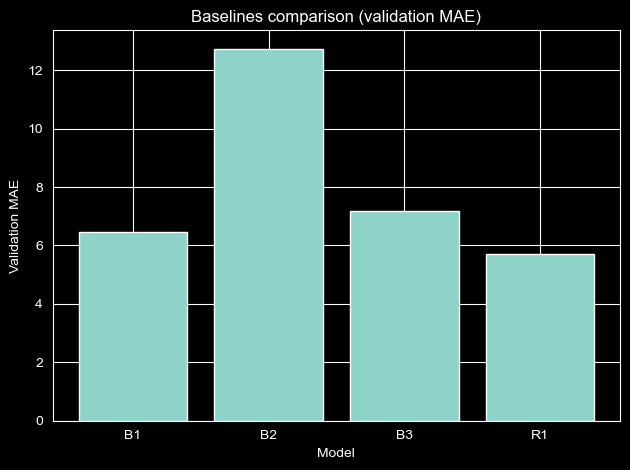

In [104]:
models = ['B1', 'B2', 'B3', 'R1']
val_mae = [b1_val_mae, b2_val_mae, b3_val_mae, r1_val_mae]

plt.figure()
plt.bar(models, val_mae)
plt.xlabel('Model')
plt.ylabel('Validation MAE')
plt.title('Baselines comparison (validation MAE)')
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()

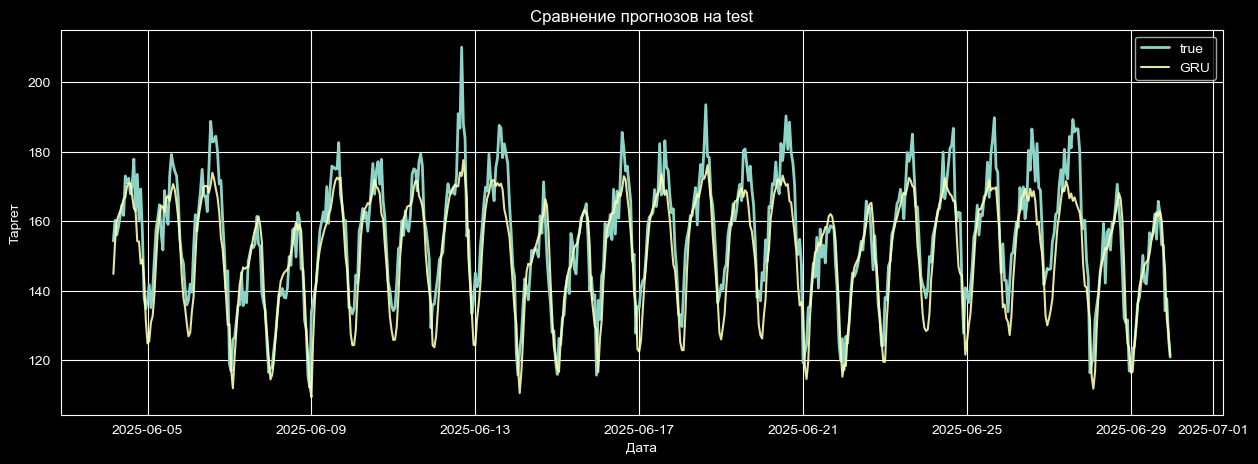

In [105]:
plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[window_size:].reset_index(drop=True),
        "true": test_true,
        "gru": gru_test_pred,
    }
)

# Строим полные прогнозы всех трех подходов
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Таргет")
ax.legend()
plt.savefig('artifacts/figures/best_forecast_test.png')
plt.show()

В моем ноутбуке основное внимание уделялось предотвращению утечек данных, и критические места были обработаны. Прежде всего, разбиение выборки выполнено строго по времени. При построении признаков для baseline-моделей лаги и rolling-статистики рассчитывались с применением shift. Масштабирование выполнялось отдельно для каждого набора: fit на обучающей выборке, transform на валидационной и тестовой. Для нейросетевой модели окна формировались только из предыдущих значений, а нормализация также настраивалась по обучающим данным. Потенциальная утечка могла бы возникнуть, если бы при создании признаков использовались будущие значения или если бы валидационная выборка как-то участвовала в подборе гиперпараметров на основе тестовых метрик, но в коде этого нет.